<a href="https://colab.research.google.com/github/danish2k04/Getting-into-Pytorch-Deep-Learning/blob/main/Binary_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

`What is a classification problem?`

A classification problem involves predicting whether something is one thing or another. such dogs or cats

In [1]:
import torch
from torch import nn
import sklearn
from sklearn.datasets import make_circles

In [2]:
# make 1000 samples
n_samples = 1000

# create circles
X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)

In [3]:
len(X), len(y)

(1000, 1000)

In [4]:
print(f"Frist 5 samples of X:\n {X[:5]}")
print(f"Frist 5 samples of y:\n {y[:5]}")

Frist 5 samples of X:
 [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
Frist 5 samples of y:
 [1 1 1 1 0]


In [5]:
# Make DataFrame of circle data
import pandas as pd
circles = pd.DataFrame({"X1": X[:, 0],
                        "X2": X[:, 1],
                        "label": y})

circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


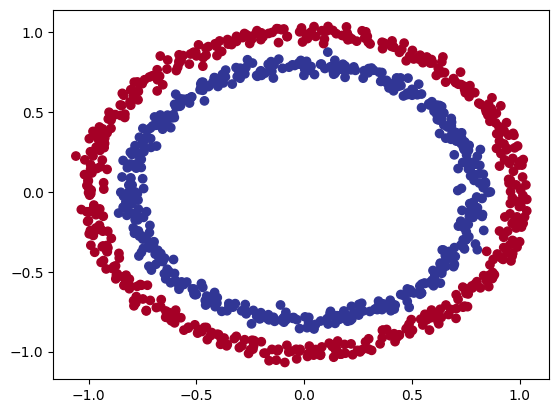

In [6]:
# Visualize
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu);

1.1 Check input and output shape

In [7]:
X.shape, y.shape

((1000, 2), (1000,))

In [8]:
# view the first emaple of feature and label
X_sample = X[0]
y_sample = y[0]

print(f'Values for one sample of X: {X_sample} and the sample for y: {y_sample}')
print(f'shape for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}')

Values for one sample of X: [0.75424625 0.23148074] and the sample for y: 1
shape for one sample of X: (2,) and the same for y: ()


1.2 turn data into tensor and create train and test sample splits

In [9]:
type(X)

numpy.ndarray

In [10]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [11]:
type(X), X.dtype, y.dtype

(torch.Tensor, torch.float32, torch.float32)

In [12]:
# Split the data into traing and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

In [13]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

## 2. Builing a model

Let's build a model to classy our blue and red dots.

To do so, we want to:
1. Setup device agnostic code so our code will run on aaccelator(GPU) if there is any
2. Contruct a model (by subclassing nn.Module)
3. Define a loss function and optimizer
4. Create a training and test loop



In [14]:
# make device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [15]:
# 1.  Construct the model
class CircleModelV0(nn.Module):
 def __init__(self):
  super().__init__()
  # 2. Create 2 nn.linear layers capable of handling the shapes of our data
  self.layer_1 = nn.Linear(in_features=2, out_features=2) # takes in 2 features and upscale it into 5 featture (usually multiple of 8)
  self.layer_2 = nn.Linear(in_features=5, out_features=1) # in feature should match the out feature of previous layer. out_feature is the output layer(same shape as y)

  '''self.two_linear_layer = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
  ).to(device)'''

  # 3. Define the forward() pass that outlines the forward pass
 def forwards(self, x):
  '''return two_linear_layer'''
  return self.layer_2(self.layer_1(x)) # x --> layer_1 --> layer_2

# 4. instantiate an instance of out model class and send it to target device
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=2, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [16]:
# Let's replicate the model above using nn.sequential()
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [17]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.1893,  0.5873],
                      [-0.5126, -0.0607],
                      [ 0.3560,  0.2269],
                      [ 0.7014,  0.6579],
                      [-0.1204,  0.4588]])),
             ('0.bias', tensor([ 0.4119,  0.0730, -0.4423, -0.1960,  0.1367])),
             ('1.weight',
              tensor([[-0.3290,  0.1852, -0.3056, -0.0112,  0.2650]])),
             ('1.bias', tensor([-0.1469]))])

In [18]:
# make some prediction
with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))
print(f'Length of prediction: {len(untrained_preds)}, shape: {untrained_preds.shape}')
print(f'Length of test samples: {len(X_test)}, shape: {X_test.shape}')
print(f'\n First 10 prediction: {untrained_preds[:10]}')
print(f'\nFirst 10 labels: {y_test[:10]}')

Length of prediction: 200, shape: torch.Size([200, 1])
Length of test samples: 200, shape: torch.Size([200, 2])

 First 10 prediction: tensor([[-0.0896],
        [-0.2533],
        [ 0.1698],
        [-0.1623],
        [-0.0997],
        [-0.1975],
        [-0.4449],
        [-0.4325],
        [ 0.1808],
        [-0.2672]])

First 10 labels: tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


# 3. setup the loss function
which loss function or optimizer to upscalefor example for regression you might want MAE ir MSE(mean absolute error or mean squared error)

for classification you might want binary class entropy or categorical cross entropy


and for the optimzer, two of the most common and useful are SGD and Adam, however Pytorch has many built in options.


In [19]:
# Setup the loss function
# loss_fn = nn.BCELoss # BCELoss = requires inputs inputs to have gone through the sigmoid activation function prior to input to BCELoss
loss_fn = nn.BCEWithLogitsLoss() #BCEWithLogitsLoss = sigmoid activation function built-in

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

In [20]:
# Calculate Accuracy
def accuracy_fn(y_true, y_preds):
  correct = torch.eq(y_true, y_preds).sum().item()
  acc = (correct/len(y_preds)) * 100
  return acc

### Training
1. Forward pass
2. Calcualt the loss
3. Optimizer zero grad
4. loss backward(Backpropagation)
5. optimize (gradient descent)


### Going from raw logits -> prediction probabilities -> pradiction labels
 our model outputs are going to be raw **raw logits**.

 WE can convert these **logits** into prediction probabilites by passing them to some kind of activation function(e.g. Sigmoid for binary crossentropy and softmax for multiclass classification)

 Then we convert our model's prediction probablities to **prediction labels** by either rounding them or taking the 'argmax()'.

In [21]:
# View first 5 outputs of the forward pass on the data
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))[:5]

y_logits

tensor([[-0.0896],
        [-0.2533],
        [ 0.1698],
        [-0.1623],
        [-0.0997]])

In [22]:
# Use the sigmoid function on our model
y_pred_probs = torch.sigmoid(y_logits)

y_pred_probs

tensor([[0.4776],
        [0.4370],
        [0.5424],
        [0.4595],
        [0.4751]])

 For our prediction probability values, we need to perform a range-style rounding on them:
 * 'y_pred_probs' >= 0.5 'y=1' (class 1)
  * 'y_pred_probs' < 0.5 'y=' (class 0)

In [23]:
# find the predicted labels
y_preds = torch.round(y_pred_probs)

# in full(logits -> preds prob -> pred labels)
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

# check for the equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# get rid of extra dimention
y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([0., 0., 1., 0., 0.])

In [24]:
# Building Training loos

In [25]:
torch.manual_seed(42)

epochs = 100
cnt_epoch = []
train_loss_values = []
test_loss_values = []

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  model_0.train()

  # 1. forward pass
  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits)) # Turn logits -> pred prob -> pred labels

  # 2. calculate the loss/ accuracy
  # loss = loss_fn(torch.sigmoid(y_logits),
  #                y_train) # nn.BCELoss expects pred prob as inputs
  loss = loss_fn(y_logits,
                 y_train) # loss function (nn.BCEWithLogitLoss) requires logits
  acc = accuracy_fn(y_true=y_train,
                    y_preds= y_pred)

  # 3.optimizer zero grad
  optimizer.zero_grad()

  # 4. backwards (backpropagation)
  loss.backward()

  # 5. optimizer step (Gradient descent)
  optimizer.step()

  # Testing
  with torch.inference_mode():
    # 1. forward pass
    test_logits = model_0(X_test).squeeze()
    y_pred_test = torch.round(torch.sigmoid(test_logits))

    # 2. calculate the loss/accuraacy
    loss_test = loss_fn(test_logits, y_test)
    test_acc= accuracy_fn(y_true=y_test,
                          y_preds=y_pred_test)

    # 3. print whats happening
    if epoch % 10 == 0:
      cnt_epoch.append(epoch)
      train_loss_values.append(loss)
      test_loss_values.append(loss_test)
      print(f'Epoch: {epoch} | Training Loss: {loss:.5f} | Train Accuracy: {acc:.2f} | Test Loss: {loss_test:.5f} | Test Accuracy: {test_acc:.2f} \n')



Epoch: 0 | Training Loss: 0.70175 | Train Accuracy: 47.38 | Test Loss: 0.69414 | Test Accuracy: 52.50 

Epoch: 10 | Training Loss: 0.69902 | Train Accuracy: 47.88 | Test Loss: 0.69296 | Test Accuracy: 53.50 

Epoch: 20 | Training Loss: 0.69723 | Train Accuracy: 48.75 | Test Loss: 0.69249 | Test Accuracy: 53.00 

Epoch: 30 | Training Loss: 0.69603 | Train Accuracy: 48.62 | Test Loss: 0.69239 | Test Accuracy: 51.50 

Epoch: 40 | Training Loss: 0.69520 | Train Accuracy: 48.88 | Test Loss: 0.69249 | Test Accuracy: 50.50 

Epoch: 50 | Training Loss: 0.69462 | Train Accuracy: 49.12 | Test Loss: 0.69270 | Test Accuracy: 49.00 

Epoch: 60 | Training Loss: 0.69421 | Train Accuracy: 49.25 | Test Loss: 0.69294 | Test Accuracy: 49.50 

Epoch: 70 | Training Loss: 0.69392 | Train Accuracy: 50.12 | Test Loss: 0.69320 | Test Accuracy: 48.50 

Epoch: 80 | Training Loss: 0.69371 | Train Accuracy: 50.38 | Test Loss: 0.69344 | Test Accuracy: 48.50 

Epoch: 90 | Training Loss: 0.69356 | Train Accuracy: 50.

##  Make prediction and evaluate the model

from thr metrics it looks like our model isn't learning anything...

So to inspect it let's make some prediction and make them visual!

visualize! visualize! visualize!

To do so,  we import are going to import a function called 'plot_dicision_boundry()'

In [26]:
import requests
from pathlib import Path

# Download helper function from LEarn Pytorch repo (if it's not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exits, skipping downloading")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)


from helper_functions import plot_predictions, plot_decision_boundary

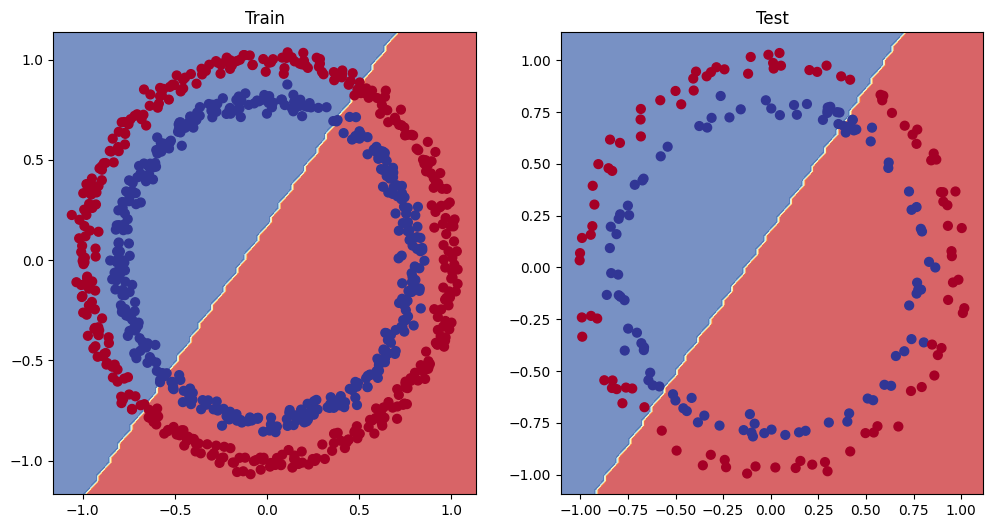

In [27]:
# Plot dicision boundary of the model
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

## 5. Improving the model(from a model perspective)
. Add more layers - given the model more to learn about the patterns in the data.

. Add more hidden units - 5 units to 10 units

. Fit for longer

. change the activation function

. change the learning rate.

. change te loss function

These are options are all from a model's perspective because theu deal directly with the model, rather than the data.

And because these options are all values we can change, the are called **hyperparameters**


In [28]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)

  def forward(self, x):
  # z = self.layer_1(x)
  # z = self.layer_2(z)
  # z = self.layer_3(z)
    return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [29]:
# loss function
loss_fn_2 = nn.BCEWithLogitsLoss()

#optimizer
optimizer_2 = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

In [30]:
epochs = 1000

torch.manual_seed(42)

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  model_1.train()

  # forward pass
  y_logits = model_1(X_train).squeeze()
  y_pred_v2 = torch.round(torch.sigmoid(y_logits))

  # calculate the loss
  loss_v1 = loss_fn_2(y_logits, y_train)
  acc = accuracy_fn(y_true=y_train,
                    y_preds=y_pred_v2)

  # optimizer zero grad
  optimizer_2.zero_grad()

  # Backpropagation
  loss_v1.backward()

  # optimzer step
  optimizer_2.step()

  ## Testing
  model_1.eval()
  with torch.inference_mode():
    # 1.forward pass
    test_logits = model_1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    # 2. calculate loss
    test_loss = loss_fn_2(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test,
                           y_preds=test_pred)
    # 3. what's happening
    if epoch % 100 == 0:
      print(f' Epochs: {epoch} | Training loss: {loss_v1} | Training Accuracy: {acc} \n Test Loss: {test_loss} | Test acccurary: {test_acc}\n')


 Epochs: 0 | Training loss: 0.6939550638198853 | Training Accuracy: 50.875 
 Test Loss: 0.6926146149635315 | Test acccurary: 51.0

 Epochs: 100 | Training loss: 0.6930477619171143 | Training Accuracy: 50.375 
 Test Loss: 0.6937903761863708 | Test acccurary: 48.0

 Epochs: 200 | Training loss: 0.692986011505127 | Training Accuracy: 51.125 
 Test Loss: 0.6943727731704712 | Test acccurary: 46.0

 Epochs: 300 | Training loss: 0.6929805278778076 | Training Accuracy: 51.625 
 Test Loss: 0.6945767998695374 | Test acccurary: 45.0

 Epochs: 400 | Training loss: 0.6929798722267151 | Training Accuracy: 51.125 
 Test Loss: 0.6946452260017395 | Test acccurary: 46.0

 Epochs: 500 | Training loss: 0.6929798722267151 | Training Accuracy: 51.0 
 Test Loss: 0.6946679949760437 | Test acccurary: 46.0

 Epochs: 600 | Training loss: 0.6929798722267151 | Training Accuracy: 51.0 
 Test Loss: 0.6946756839752197 | Test acccurary: 46.0

 Epochs: 700 | Training loss: 0.6929798722267151 | Training Accuracy: 51.0 


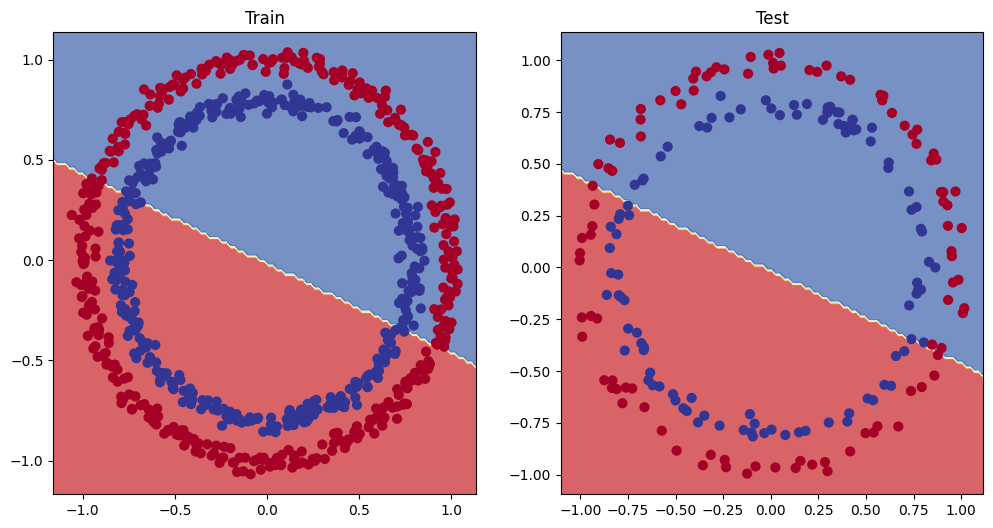

In [31]:
# Plot dicision boundary of the model
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

### 6.2 Building a model with non-linearlarty

In [32]:
# Build a mdoel with non-linear functions

from torch import nn
class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)
    self.relu = nn.ReLU()

  def forward(self, x):
    # Where should we put our non_linear activation function?
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = CircleModelV2().to(device)

model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [33]:
# Create loss function and optimizer

# loss_fn = nn.BCELoss # BCELoss = requires inputs inputs to have gone through the sigmoid activation function prior to input to BCELoss
loss_fn = nn.BCEWithLogitsLoss() #BCEWithLogitsLoss = sigmoid activation function built-in

optimizer = torch.optim.SGD(params=model_3.parameters(), lr=0.1)


In [34]:
# Training
torch.manual_seed(42)
torch.cuda.manual_seed(42)
epochs = 10000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)


for epoch in range(epochs):
  model_3.train()

  # forward
  y_logits = model_3(X_train).squeeze(dim=1)
  y_preds = torch.round(torch.sigmoid(y_logits))

  # Calculate the loss
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_true=y_train,
                    y_preds=y_preds)

  # optimzer Zero grad
  optimizer.zero_grad()

  # loss backwards
  loss.backward()

  # optimize
  optimizer.step()

  model_3.eval()
  with torch.inference_mode():
    # forward pass
    test_logits = model_3(X_test).squeeze(dim=1)
    test_pred = torch.round(torch.sigmoid(test_logits))

    # calculate the loss
    test_loss_logits = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test,
                           y_preds=test_pred)
    # print
    if epoch % 100 == 0:
      print(f'Epochs: {epoch} | Train Loss: {loss} | Training Accuracy: {acc} \n Test Loss: {test_loss} | Test Accuracy: {test_acc}\n')



Epochs: 0 | Train Loss: 0.6929463148117065 | Training Accuracy: 50.0 
 Test Loss: 0.6946794986724854 | Test Accuracy: 50.0

Epochs: 100 | Train Loss: 0.6911528706550598 | Training Accuracy: 52.87500000000001 
 Test Loss: 0.6946794986724854 | Test Accuracy: 52.5

Epochs: 200 | Train Loss: 0.6897743940353394 | Training Accuracy: 53.37499999999999 
 Test Loss: 0.6946794986724854 | Test Accuracy: 55.00000000000001

Epochs: 300 | Train Loss: 0.687949538230896 | Training Accuracy: 53.0 
 Test Loss: 0.6946794986724854 | Test Accuracy: 56.00000000000001

Epochs: 400 | Train Loss: 0.6851678490638733 | Training Accuracy: 52.75 
 Test Loss: 0.6946794986724854 | Test Accuracy: 56.49999999999999

Epochs: 500 | Train Loss: 0.6810224652290344 | Training Accuracy: 52.75 
 Test Loss: 0.6946794986724854 | Test Accuracy: 56.49999999999999

Epochs: 600 | Train Loss: 0.675148606300354 | Training Accuracy: 54.50000000000001 
 Test Loss: 0.6946794986724854 | Test Accuracy: 56.00000000000001

Epochs: 700 | Tr

## 6.4 Evalute a modle trained with mnon_linear activation function

In [35]:
model_3.eval()
with torch.inference_mode():
  y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()

y_preds[:10], y_test[:10]

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

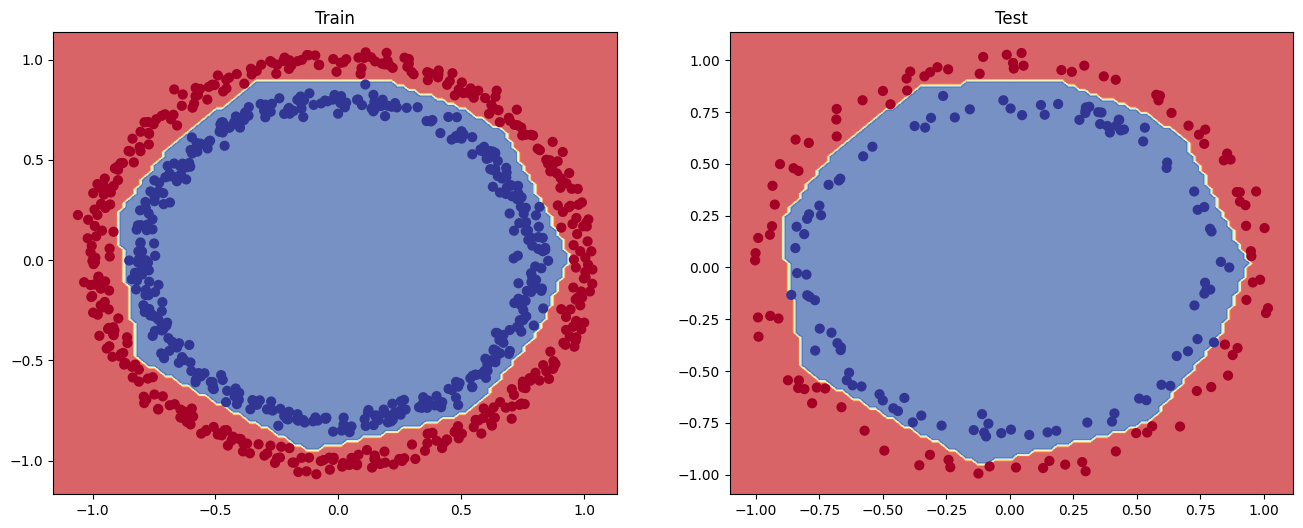

In [36]:
# plot dicision boundary
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_3, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test)